### Question: Glucose trend forecasting

**Reasons:**

Glucose trend forecasting is important for predictive analysis because it helps anticipate how a person’s blood sugar levels will change over time instead of just describing what has already happened.

Here’s why it matters:

1. Early risk detection
By forecasting glucose trends, you can identify patterns that may lead to hypoglycemia (low sugar) or hyperglycemia (high sugar) before they occur, enabling early intervention.

2. Better diabetes management
For conditions like Diabetes mellitus, glucose levels fluctuate due to food intake, activity, stress, and medication. Forecasting helps adjust insulin doses, meals, or exercise plans proactively.

3. Personalized healthcare decisions
Each patient has unique glucose behavior. Predictive models help tailor treatment plans rather than using a one-size-fits-all approach.

4. Prevent complications
Long-term uncontrolled glucose can lead to serious issues like nerve damage, kidney disease, and cardiovascular problems. Forecasting reduces these risks by enabling timely control.

5. Supports data-driven decisions
In predictive analytics, the goal is not just understanding past data but using it to predict future outcomes. Glucose forecasting is a direct application of this principle in healthcare analytics.

In short, glucose trend forecasting turns raw historical data into actionable predictions that improve health outcomes and decision-making.

Mean Absolute Error: 2.9511588077102644
R2 Score: 0.9910990530488585
   Actual Glucose  Predicted Glucose
0           88.50          71.161990
1          142.67         143.982280
2          167.00         170.972950
3          139.67         141.161272
4           54.27          54.455448
5           76.00          72.514717
6          140.67         138.056621
7          224.67         213.717408
8          198.67         198.274357
9          138.00         133.835302


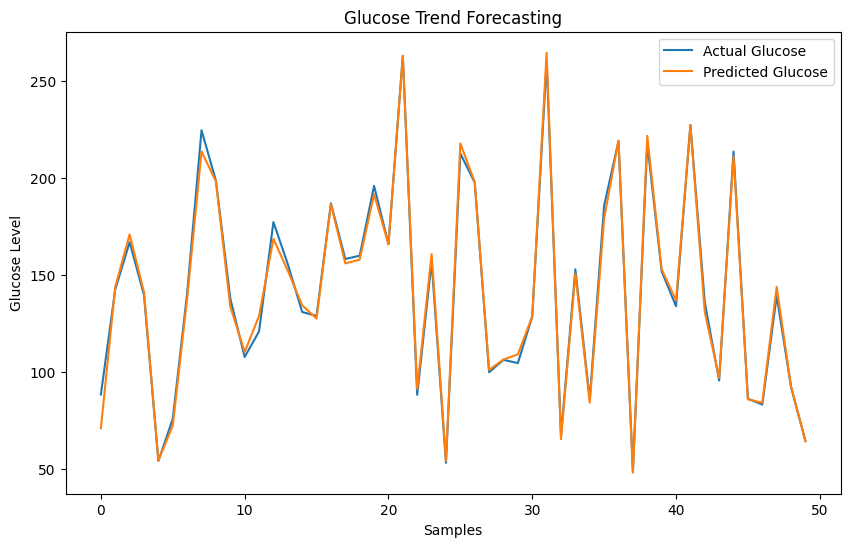

In [1]:
# Glucose Trend Forecasting using Linear Regression
# -----------------------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# -----------------------------------------------
# LOAD DATA
# -----------------------------------------------

# Replace with your dataset file
df = pd.read_excel("Team6_DataDynamos_Python-Hackathon_MAY2026_V2.xlsx")

# -----------------------------------------------
# SELECT FEATURES
# -----------------------------------------------

# Example input features
features = [
    'glucose',
    'calories',
    'heart_rate',
    'steps',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input'
]

# -----------------------------------------------
# CREATE FUTURE GLUCOSE TARGET
# -----------------------------------------------

# Predict next glucose reading
df['future_glucose'] = df['glucose'].shift(-1)

# Remove last row with NaN target
df = df.dropna()

# -----------------------------------------------
# INPUT (X) AND OUTPUT (y)
# -----------------------------------------------

X = df[features]
y = df['future_glucose']

# -----------------------------------------------
# TRAIN TEST SPLIT
# -----------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------------------
# TRAIN MODEL
# -----------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------------------------
# PREDICTIONS
# -----------------------------------------------

y_pred = model.predict(X_test)

# -----------------------------------------------
# EVALUATION
# -----------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# -----------------------------------------------
# SHOW SAMPLE PREDICTIONS
# -----------------------------------------------

results = pd.DataFrame({
    'Actual Glucose': y_test.values,
    'Predicted Glucose': y_pred
})

print(results.head(10))

# -----------------------------------------------
# PLOT ACTUAL VS PREDICTED
# -----------------------------------------------

plt.figure(figsize=(10,6))
plt.plot(y_test.values[:50], label='Actual Glucose')
plt.plot(y_pred[:50], label='Predicted Glucose')

plt.xlabel("Samples")
plt.ylabel("Glucose Level")
plt.title("Glucose Trend Forecasting")

plt.legend()
plt.show()

In [2]:
# ---------------------------------------------------------
# TEST DATA FOR BEST MODEL (Random Forest)
# ---------------------------------------------------------

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
# ---------------------------------------------------------
# CREATE FUTURE GLUCOSE
# ---------------------------------------------------------

df['future_glucose'] = df['glucose'].shift(-1)

# Remove missing values
df = df.dropna()

# ---------------------------------------------------------
# CREATE TARGET VARIABLE
# ---------------------------------------------------------

# Hyperglycemia = Future glucose > 180
df['hyperglycemia'] = np.where(
    df['future_glucose'] > 180,
    1,
    0
)

# ---------------------------------------------------------
# SELECT FEATURES
# ---------------------------------------------------------

features = [
    'glucose',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input',
    'calories',
    'steps',
    'heart_rate',
    'average_sleep_duration_(hrs)'
]

X = df[features]
y = df['hyperglycemia']

# ---------------------------------------------------------
# SPLIT DATA
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------
# TRAIN BEST MODEL
# ---------------------------------------------------------

best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

best_model.fit(X_train, y_train)

# ---------------------------------------------------------
# TEST MODEL
# ---------------------------------------------------------

# Predict on test data
y_pred = best_model.predict(X_test)

# ---------------------------------------------------------
# MODEL PERFORMANCE
# ---------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("================================================")
print("TEST RESULTS FOR RANDOM FOREST MODEL")
print("================================================")

print("\nAccuracy Score:", round(accuracy, 4))

# ---------------------------------------------------------
# CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

# ---------------------------------------------------------
# SHOW ACTUAL VS PREDICTED
# ---------------------------------------------------------

test_results = pd.DataFrame({

    'Actual': y_test.values,
    'Predicted': y_pred

})

print("\n================================================")
print("ACTUAL VS PREDICTED RESULTS")
print("================================================")

print(test_results.head(20))

# ---------------------------------------------------------
# PREDICT NEW PATIENT DATA
# ---------------------------------------------------------

# Example new patient test data
new_patient = pd.DataFrame({

    'glucose': [190],
    'basal_rate': [1.2],
    'bolus_volume_delivered': [3],
    'carb_input': [75],
    'calories': [600],
    'steps': [1000],
    'heart_rate': [95],
    'average_sleep_duration_(hrs)': [5]

})

# Predict Hyperglycemia Risk
prediction = best_model.predict(new_patient)

# Prediction Probability
probability = best_model.predict_proba(new_patient)

print("\n================================================")
print("NEW PATIENT PREDICTION")
print("================================================")

if prediction[0] == 1:
    print("Predicted Result : Hyperglycemia Risk")
else:
    print("Predicted Result : Normal")

print("\nPrediction Probability:")
print(probability)

TEST RESULTS FOR RANDOM FOREST MODEL

Accuracy Score: 0.9851

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     48442
           1       0.97      0.96      0.97     13436

    accuracy                           0.99     61878
   macro avg       0.98      0.98      0.98     61878
weighted avg       0.99      0.99      0.99     61878


Confusion Matrix:

[[48022   420]
 [  505 12931]]

ACTUAL VS PREDICTED RESULTS
    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        1          1
8        0          0
9        1          1
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       1          1
17       0          0
18       0          0
19       0          0

NEW PATIENT PREDICTION
Predicted Result : Hy

In [3]:
# ---------------------------------------------------------
# PREDICT NEW PATIENT DATA
# ---------------------------------------------------------

# Example new patient test data
new_patient = pd.DataFrame({

    'glucose': [300],
    'basal_rate': [1.2],
    'bolus_volume_delivered': [0],
    'carb_input': [75],
    'calories': [600],
    'steps': [100000],
    'heart_rate': [95],
    'average_sleep_duration_(hrs)': [7]

})

# Predict Hyperglycemia Risk
prediction = best_model.predict(new_patient)

# Prediction Probability
probability = best_model.predict_proba(new_patient)

print("\n================================================")
print("NEW PATIENT PREDICTION")
print("================================================")

if prediction[0] == 1:
    print("Predicted Result : Hyperglycemia Risk")
else:
    print("Predicted Result : Normal")

print("\nPrediction Probability:")
print(probability)


NEW PATIENT PREDICTION
Predicted Result : Hyperglycemia Risk

Prediction Probability:
[[0.28 0.72]]
